In [1]:
import matplotlib.pyplot as plt
from draw_rna.ipynb_draw import draw_struct
from draw_rna.wrapper_functions import predict_structure, create_figure, get_ct, get_energy_list
import os
import re
from RNA import RNA
import matplotlib as mpl
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2   

import numpy as np

In [32]:
def get_ct(file_path):
    with open(file_path, 'r') as file:
        seq = file.readline().strip()
        print(len(seq))
        struct = file.readline().strip()
    return seq, struct

def get_energy_list(seq, struct):
    energy_list = {}
    external_values = 0
    with open('tmp.txt', 'w') as file:
        RNA.eval_structure_simple(seq, struct, 1, file)
    with open('tmp.txt', 'r') as file:
        for line in file.readlines():
            stripped = line.strip()
            val = int(stripped.split(':')[-1])
            digits = re.findall(r'\d+', stripped)
            digits = digits[:-1]
            digits = digits[0:2]
            if len(digits) == 0: external_values += val/100
            else:
                digit = int(digits[0])
                energy_list[digit-1] = val/100
                digit = int(digits[1])
                energy_list[digit-1] = val/100
    os.remove('tmp.txt')
    return energy_list

def ct_to_paired_list_count_all(file_path, predict=False, constraints=None):
    if predict:
        seq, db = get_ct(file_path)
        db = predict_structure(seq, constraints)
        print(db)
    else:
        seq, db = get_ct(file_path)
    i, j = 0, len(db)-1
    stack = []
    structures = []
    while i < len(db) and db[i] == '.':
        stack.append((i, db[i]))
        i+=1
    while i < len(db):
        while i < len(db) and (db[i] == '(' or  db[i] == '.'):
            stack.append((i, db[i]))
            i += 1
        tmp_struct = []
        cnt = 0
        while len(stack) and stack[-1][1] == '.': 
            stack.pop()
            cnt += 1
        while i < len(db) and len(stack) and \
                ((stack[-1][1] == '(' and db[i] == ')') or
                 (len(stack) >= 2 and stack[-1][1] == '.' and stack[-2][1] == '(' and db[i] == ')') or
                 (i+1 < len(db) and stack[-1][1] == '(' and db[i] == '.' and db[i+1] == ')')):
            match = stack.pop()
            if match[1] == '.': 
                match = stack.pop()
                cnt+=1
            if db[i] == '.': 
                i+=1
                cnt += 1
            tmp_struct.append((match[0], i))
            i+=1
        tmp_struct.append(cnt) # number of unpaired in center
        if tmp_struct:
            structures.append(tmp_struct)
    while len(stack):
        val = stack.pop()
        if val[1] != '.': 
            print("Error", val, i)
        if len(structures) > 0  and isinstance(structures[-1][0], int): 
            structures[-1][0] += 1
        else:
            structures.append([1])
    final_list = []
    for struc in structures:
        if len(struc) == 1: 
            final_list.append(struc[0]+len(stack)-1)
            continue
        unpaired_middle, start, end = struc[-1], struc[0], struc[-2]
        bases = (len(struc)-1)*2+struc[-1]
        length = round(bases*0.59,2)
        middle_bases = struc[int((len(struc)-1)/2)]
        position = int((start[0]-end[0])/2)+end[0]
        final_list.append((position, bases, length, middle_bases))
    str_list = []
    for item in final_list:
        if not isinstance(item, tuple): continue
        # str_list.append((item[0], f"{item[0]}\n{item[1]}\n{item[2]}", item[3])) # nm bp and middle 
        # str_list.append((item[0], f"{item[1]}\n{item[2]}nm", item[3])) # nm and bp
        str_list.append((item[0], f"{item[2]}nm", item[3])) # only nm
    return final_list, str_list, seq, db, structures

def map_energy_to_color(energies, structures, seq, energies_individual=False):
    grey = (169,169,169)
    cmap = plt.get_cmap('seismic')
    energy_vals = np.array(list(energies.values()))
    max_energy = np.max(np.absolute(energy_vals))
    norm = mpl.colors.Normalize(vmin=-max_energy, vmax=max_energy)
    scalarMap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    colors = []
    for char in seq:
        colors.append(grey)
    if energies_individual:
        for segment in structures:
            for pairs in segment[:-1]:
                if pairs[0] in energies:
                    energy = energies[pairs[0]]
                else:
                    energy = energies[pairs[1]]
                colors[pairs[0]] = scalarMap.to_rgba(energy, bytes=True)[:-1]
                colors[pairs[1]] = scalarMap.to_rgba(energy, bytes=True)[:-1]
    else:
        for segment in structures:
            total_energy = 0
            for pairs in segment[:-1]:
                if pairs[0] in energies:
                    energy = energies[pairs[0]]
                else:
                    energy = energies[pairs[1]]
                total_energy += energy
            if total_energy:
                total_energy /= len(segment[:-1])
            for pairs in segment[:-1]:
                colors[pairs[0]] = scalarMap.to_rgba(total_energy, bytes=True)[:-1]
                colors[pairs[1]] = scalarMap.to_rgba(total_energy, bytes=True)[:-1]
    segment_energy = []
    for segment in structures:
        total_energy = 0
        for pairs in segment[:-1]:
            if pairs[0] in energies:
                energy = energies[pairs[0]]
            else:
                energy = energies[pairs[1]]
            total_energy += energy
        if total_energy:
            total_energy /= len(segment[:-1])
            segment_energy.append(total_energy)
        
    return colors, scalarMap, segment_energy

def predict_structure(sequence, constraints=None):
    db_input = '.'*len(sequence)
    if constraints:
        db_input = list(db_input)
        for constraint in constraints:
            db_input[constraint] = 'x'
        db_input = ''.join(db_input)
        print(db_input)
        
    fc = RNA.fold_compound(sequence)
    fc.hc_add_from_db(db_input)
    (ss, mfe) = fc.mfe()
    print("energy", mfe)
    return ss

# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/dots/1.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_UNRESTRAINED_cleaned.txt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_RESTRAINED_cleaned.txt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/2.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/unfolding_steps/tmp.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/dots/1_tmp.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR-presentation/dots/1.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/1.dt'
def create_figure(file_path, predict=False, large_mode=False, black_white=False, store_plt_svg=True, file_name=None, numbering=False, segment_lenghts=True, show_energies=False, energies_individual=False, custom_line=False, constraints=None, line=False, add_fake=[]):
    final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file_path, predict, constraints)
    print(f"free bases, {structures[-1][0]} nm: {structures[-1][0] * 0.59}")
    energies = get_energy_list(seq, db)
    colors, scalar_map = None, None
    if show_energies:
        colors, scalar_map, segment_energy = map_energy_to_color(energies, structures, seq, energies_individual)
        for idx, (segment_str, seg_energy) in enumerate(zip(final_str_list, segment_energy)):
            seg2 = segment_str[2]
            if add_fake:
                for fake in add_fake:
                    if fake[0] <= seg2[0]:
                        seg2 = (seg2[0]+fake[1], seg2[1])  
                    if fake[0] <= seg2[1]:
                        seg2 = (seg2[0], (seg2[1]+fake[1]))  
            final_str_list[idx] = (segment_str[0], segment_str[1]+f"\n{round(seg_energy,2)}", seg2) 
        print(final_str_list)
    if file_name is None:
        file_name=file_path.split('.')[0]
    if not segment_lenghts:
        final_str_list = None
    if numbering: numbering=[list(range(1,len(seq)+1)), numbering]
    else: numbering = None
    if black_white: seq = None
    else: seq = seq.upper()
    if add_fake:
        for fake in add_fake[::-1]:
            seq = seq[0:fake[0]]+'@'*fake[1]+seq[fake[0]:]
            db = db[0:fake[0]]+'@'*fake[1]+db[fake[0]:]
            if colors: colors = colors[0:fake[0]]+['@']*fake[1]+colors[fake[0]:]
            if numbering: numbering[0] = numbering[0][0:fake[0]]+['@']*fake[1]+numbering[0][fake[0]:]
    draw_struct(seq, db, c=colors, cmap='RdBu_r', scalar_map=scalar_map,  custom_text=final_str_list, store_plt_svg=store_plt_svg, filename=file_name, large_mode=large_mode, numbering=numbering, custom_line=custom_line, line=line)
    # draw_struct(seq, db, c=colors, cmap='RdBu_r', scalar_map=scalar_map,  custom_text=final_str_list, store_plt_svg=store_plt_svg, filename=file_name, large_mode=large_mode, numbering=numbering)


208
free bases, 6 nm: 3.54
[(42, '21.24nm\n-2.42', (41, 62)), (95, '3.54nm\n5.3', (95, 100)), (92, '3.54nm\n3.4', (92, 103)), (89, '3.54nm\n-0.2', (89, 106)), (85, '4.72nm\n1.0', (85, 110)), (78, '11.8nm\n-1.49', (78, 117)), (145, '7.08nm\n-0.15', (145, 154)), (140, '4.72nm\n-0.2', (140, 159)), (131, '10.62nm\n2.1', (131, 168)), (127, '4.72nm\n-0.55', (127, 172)), (124, '4.72nm\n-1.23', (124, 175)), (30, '11.8nm\n-0.67', (30, 183)), (22, '13.57nm\n-2.36', (22, 192)), (9, '13.57nm\n-0.93', (9, 202))]
saving svg as IGR-L-with-linkers.svg


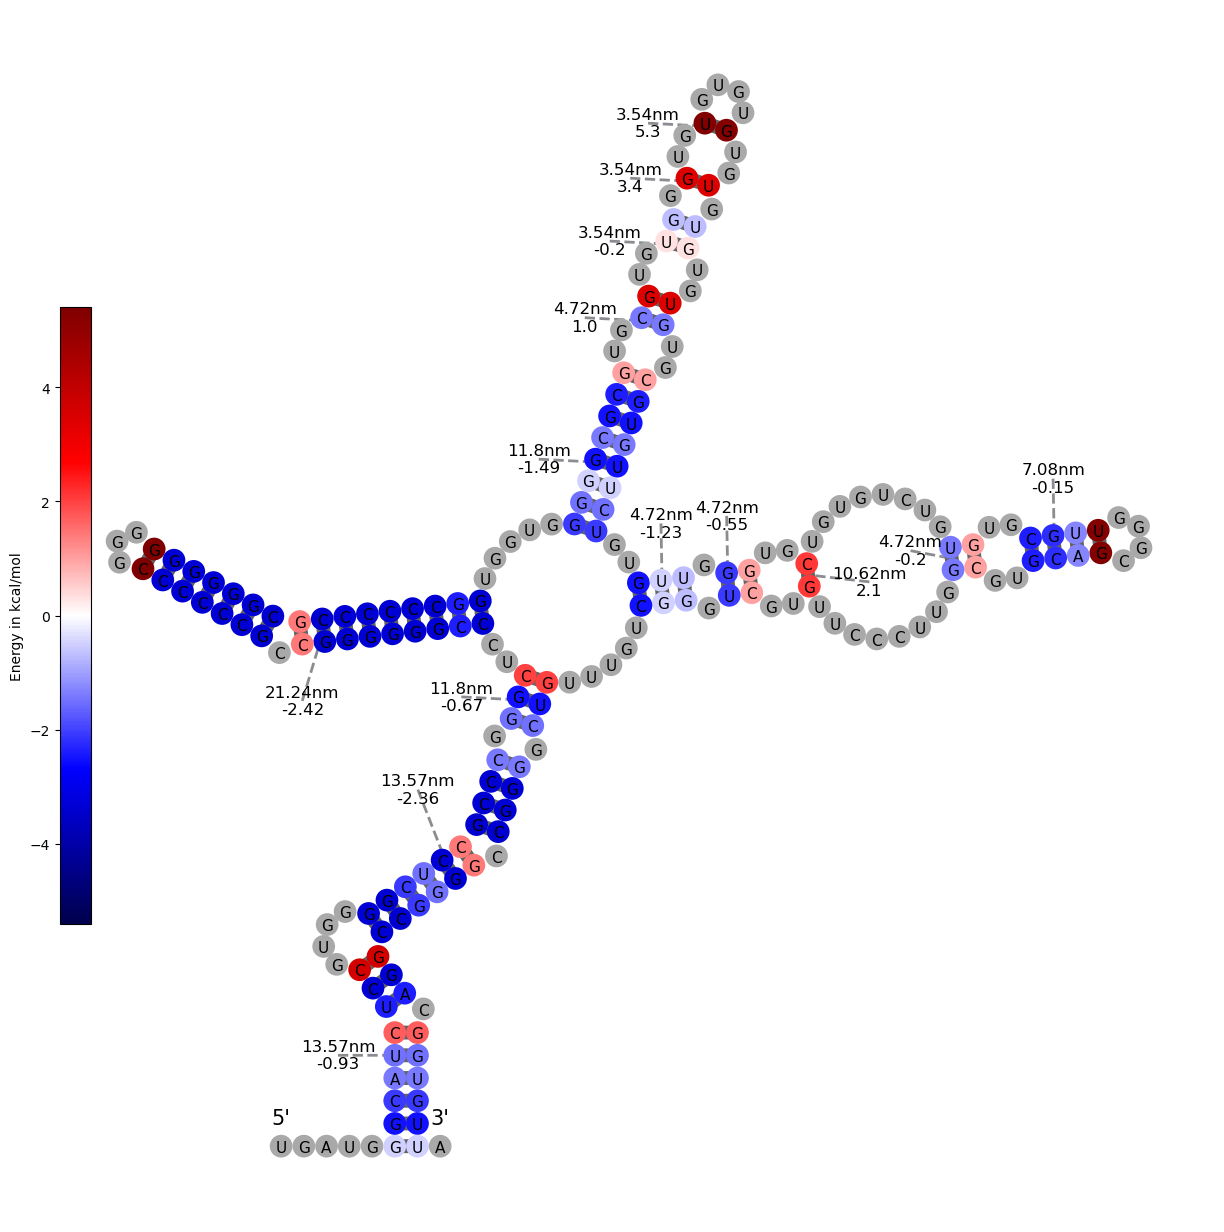

208
energy -100.5
.....(((((((((....((((((((((.((((((((((((((.(((((((...)))))))))))))))).))..((((((((((((......................))))))))))))..(((.(((((........((((((((....))))))))........))))).))).....))).))).)))))))))).)))))).
free bases, 6 nm: 3.54
[(41, '24.19nm\n-2.21', (42, 65)), (80, '27.14nm\n-0.98', (82, 117)), (143, '11.8nm\n-0.84', (145, 158)), (129, '15.34nm\n-0.94', (131, 172)), (124, '4.72nm\n-1.23', (126, 177)), (30, '8.85nm\n-0.43', (30, 185)), (22, '13.57nm\n-2.36', (22, 194)), (9, '13.57nm\n-0.93', (9, 204))]
saving svg as /home/dwarrel/Documents/figures/SP_writing/data-to-figure-comparing/IGR-L-with-linkers.svg


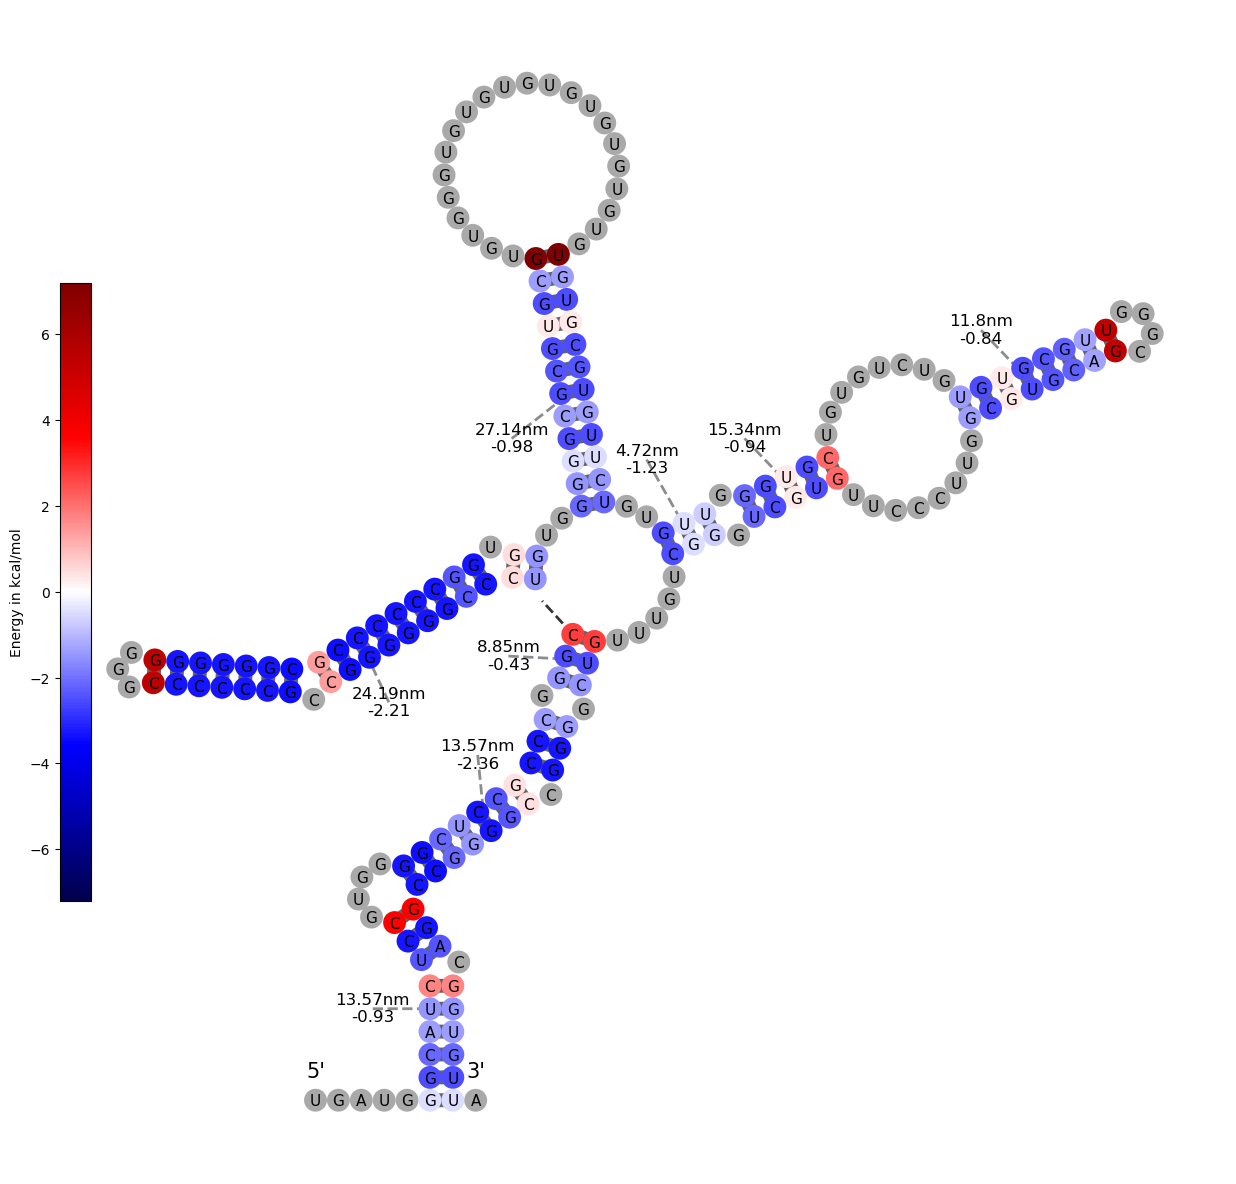

In [39]:
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_UNRESTRAINED.txt'
file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/dots/1_removed_linkers.dt'
name = 'IGR-L-with-linkers'
# name = file_path.split('/')[-1].strip('.txt')
store_path = '/home/dwarrel/Documents/figures/SP_writing/data-to-figure-comparing/'
create_figure(file_path, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{name}.svg', numbering=False, custom_line=True, store_plt_svg=True)
create_figure(file_path, predict=True, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{store_path}IGR-L-with-linkers.svg', numbering=False, custom_line=True, store_plt_svg=True, add_fake=[(32,2)])
file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_UNRESTRAINED.txt'
name = file_path.split('/')[-1].strip('.txt')
# create_figure(file_path, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{name}.svg', numbering=False, custom_line=True, store_plt_svg=True)
file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_RESTRAINED.txt'
name = file_path.split('/')[-1].strip('.txt')
# create_figure(file_path, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{name}.svg', numbering=False, custom_line=True, store_plt_svg=True)
file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_RESTRAINED_reduced-to-ot-size'
name = file_path.split('/')[-1].strip('.txt')
# create_figure(file_path, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{name}.svg', numbering=False, custom_line=True, store_plt_svg=True)
# create_figure(file_path, predict=True, show_energies=False, energies_individual=True, large_mode=True, file_name=f'{store_path}IGR-L-with-linkers.svg', numbering=True, custom_line=True, store_plt_svg=True, add_fake=[(32,2)])
# create_figure(file_path, predict=True, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{store_path}{name}.svg', numbering=False, custom_line=True, store_plt_svg=True, add_fake=[(32,2)])
# constraints=list(range(0,14))+list(range(197,208))
# print(constraints)
# create_figure(file_path, predict=True, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{store_path}{name}-1.svg', numbering=False, custom_line=True, store_plt_svg=True, constraints=constraints, line=False, add_fake=[(25,1),(32,5)])
# constraints=list(range(0,25))+list(range(186,208))
# create_figure(file_path, predict=True, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{store_path}{name}-2.svg', numbering=False, custom_line=True, store_plt_svg=True, constraints=constraints, line=False, add_fake=[(30,4)])

# constraints=list(range(0,34))+list(range(186,208))
# create_figure(file_path, predict=True, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{store_path}{name}-3.svg', numbering=True, custom_line=True, store_plt_svg=True, constraints=constraints, line=False, add_fake=[(73,4),(123,3)])

208
free bases, 15 nm: 8.85
[(50, '18.88nm\n-1.18', (52, 71)), (92, '7.08nm\n6.4', (96, 107)), (82, '20.06nm\n-1.03', (86, 117)), (143, '11.8nm\n-0.84', (147, 160)), (129, '15.34nm\n-0.94', (133, 174)), (124, '4.72nm\n-1.23', (128, 179)), (40, '6.49nm\n-0.4', (42, 184)), (33, '11.21nm\n-2.17', (35, 191)), (24, '10.03nm\n-2.24', (26, 200)), (19, '3.54nm\n0.4', (19, 207)), (16, '4.72nm\n-0.73', (16, 210))]
saving svg as ct2dot_LCMVL_RESTRAINED_reduced-to-ot-size.svg


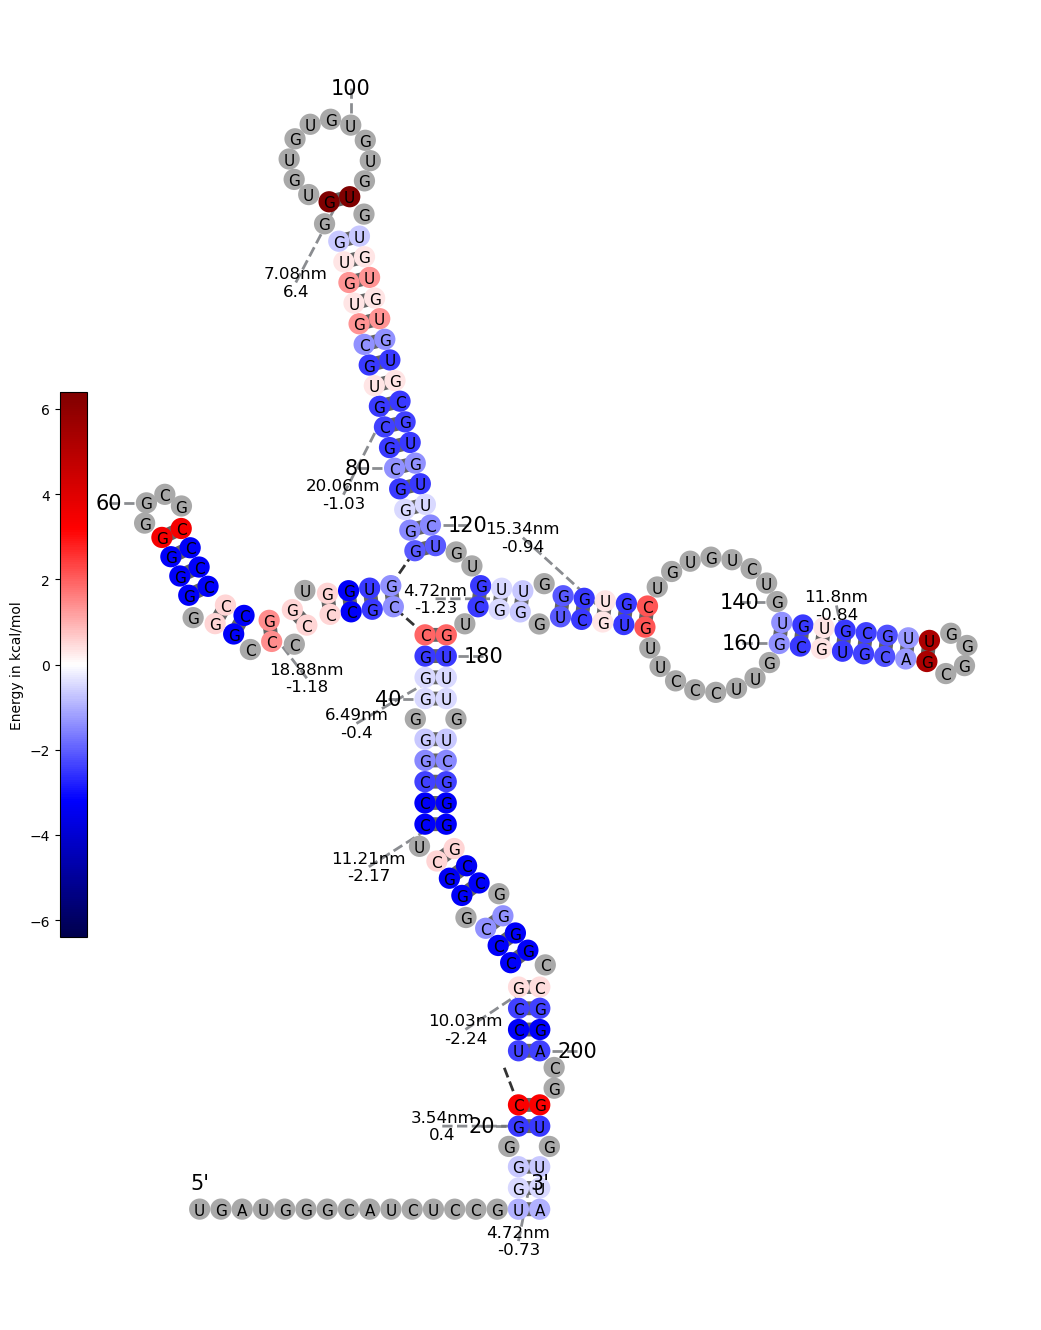

208
free bases, 6 nm: 3.54
[(41, '23.01nm\n-2.25', (42, 63)), (92, '7.08nm\n6.4', (93, 104)), (82, '20.06nm\n-1.03', (83, 114)), (143, '11.8nm\n-0.84', (144, 157)), (129, '15.34nm\n-0.94', (130, 171)), (124, '4.72nm\n-1.23', (125, 176)), (30, '10.03nm\n-0.83', (30, 184)), (22, '13.57nm\n-2.36', (22, 193)), (9, '13.57nm\n-0.93', (9, 203))]
saving svg as ct2dot_LCMVL_UNRESTRAINED_reduced-to-ot-size.svg


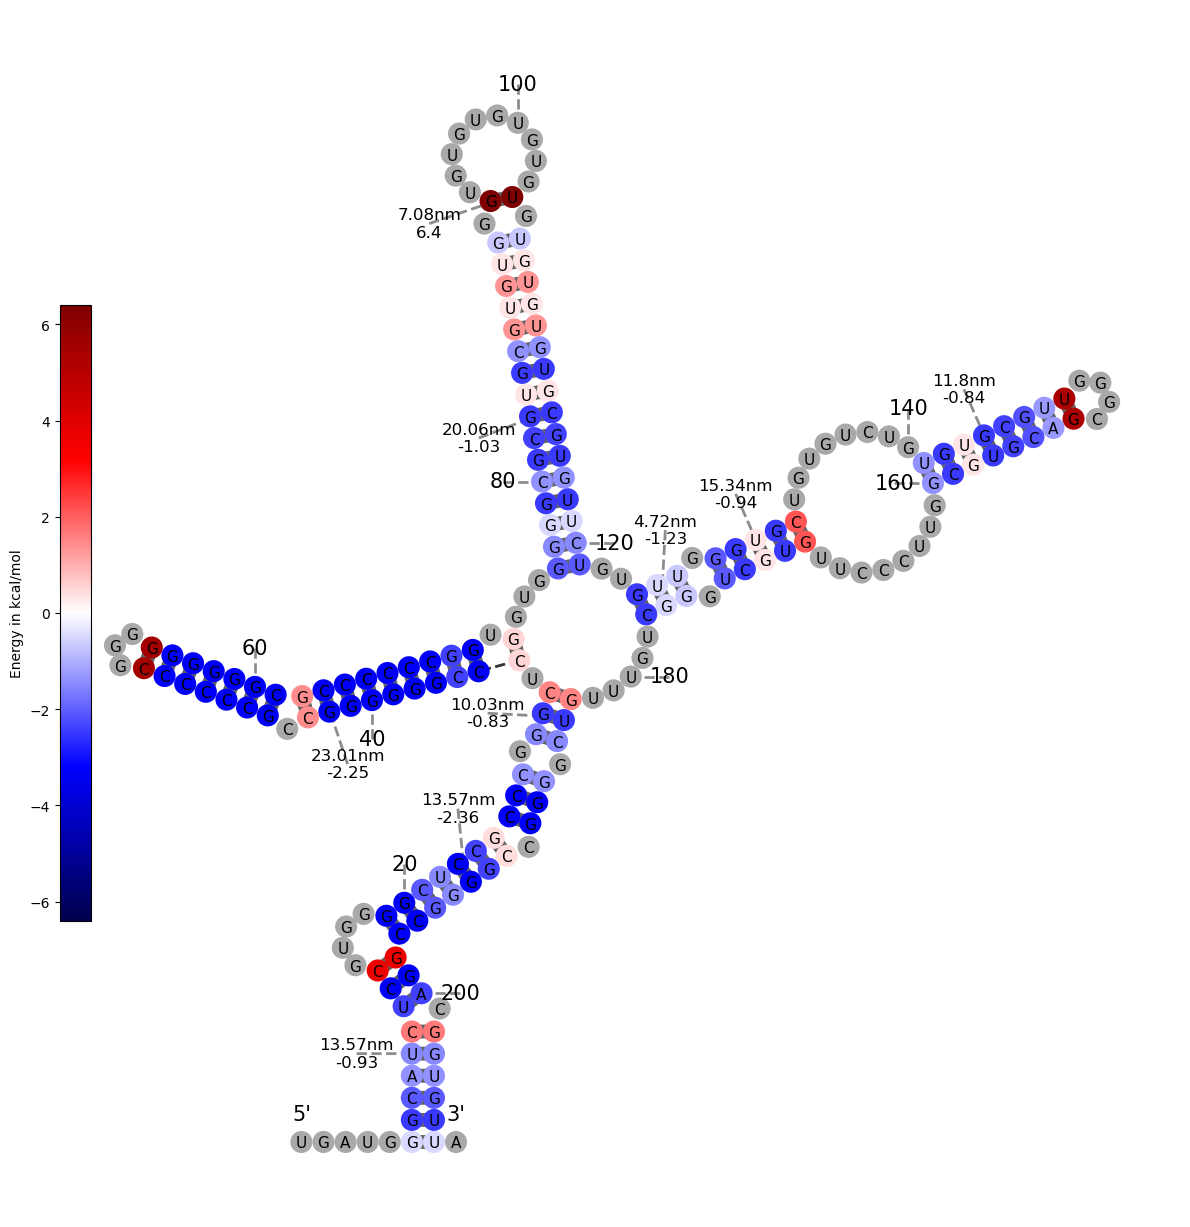

In [35]:
file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_RESTRAINED_reduced-to-ot-size'
name = file_path.split('/')[-1].strip('.txt')
create_figure(file_path, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{name}.svg', numbering=20, custom_line=True, store_plt_svg=True, add_fake=[(21,2),(43,1),(75,1)])
file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_UNRESTRAINED_reduced-to-ot-size'
name = file_path.split('/')[-1].strip('.txt')
create_figure(file_path, show_energies=True, energies_individual=True, large_mode=True, file_name=f'{name}.svg', numbering=20, custom_line=True, store_plt_svg=True, add_fake=[(34,1)])